# Entrega 1 - CoderHouse - Data Science 1
## Estudiante: Agustina Belen Yañez

# Abstract

El dataset elegido para este proyecto contiene información sobre distintos factores que pueden influir en el rendimiento académico de los estudiantes. La idea es analizar qué variables impactan más en los puntajes de examen y, a partir de eso, poder anticipar cómo se desempeñan los alumnos. Entre las variables incluidas están: horas de estudio, asistencia a clase, motivación, apoyo de los padres, acceso a recursos educativos, participación en actividades extracurriculares, situación familiar, nivel socioeconómico, distancia desde el hogar y otros aspectos que pueden marcar la diferencia en los resultados.

La pregunta que guía este análisis es: ¿Qué factores influyen más en el rendimiento académico y cómo se relacionan entre sí? Esto permite no solo identificar los determinantes más importantes del desempeño, sino también entender patrones y situaciones que se repiten o que son excepcionales dentro del grupo de estudiantes.

El objetivo del proyecto es generar un panorama claro de qué aspectos favorecen un mejor rendimiento y cuáles podrían estar limitando los resultados, considerando tanto factores individuales como contextuales. Esto ayuda a tener una visión más completa de la situación académica de los estudiantes y sienta las bases para futuros análisis o modelos predictivos que puedan anticipar el desempeño y orientar estrategias de estudio o acompañamiento educativo.

# Preguntas de interes

* ¿Qué factores influyen más en el rendimiento académico de los estudiantes (Exam_Score)?

* ¿Cómo se relacionan las horas de estudio, la asistencia y la motivación con los puntajes obtenidos?

* ¿El acceso a recursos educativos, la participación de los padres o la distancia desde el hogar afectan significativamente el desempeño?

* ¿Existen diferencias claras en el rendimiento entre estudiantes con distintos niveles de apoyo familiar, socioeconómico o escolar?

* ¿Se pueden identificar casos excepcionales que difieran del comportamiento general del grupo y qué características tienen?

# Hipotesis

Para este análisis, se plantean los siguientes contrastes de hipótesis basados en las variables del dataset:

## Escenario 1: Impacto de Factores Académicos Directos
* Hipótesis Nula ($H_0$): No existe una relación lineal significativa entre las horas de estudio (Hours_Studied), la asistencia (Attendance) y el puntaje final del examen (Exam_Score).

* Hipótesis Alternativa ($H_1$): Existe una correlación positiva y significativa, a mayor cantidad de horas de estudio y porcentaje de asistencia, el puntaje del examen aumenta.

## Escenario 2: Influencia del Entorno y Recursos

* Hipótesis Nula ($H_0$): El acceso a recursos educativos (Access_to_Resources) y el nivel de apoyo parental (Parental_Involvement) no generan diferencias significativas en el promedio de las notas de los estudiantes.

* Hipótesis Alternativa ($H_1$): Los estudiantes con alto acceso a recursos y alto apoyo parental presentan una media de puntaje (Exam_Score) significativamente superior a los que tienen niveles bajos en estas variables.

# Definición del Marco del Proyecto

* **Objetivo**: Predecir el puntaje final de los exámenes (Exam_Score) basándose en factores socio-educativos y hábitos de estudio.

* **Contexto Comercial:** Una institución educativa busca identificar a tiempo a los alumnos en riesgo académico para asignar tutores o recursos de apoyo de manera eficiente. La optimización de recursos (tutores) permitirá reducir costos operativos al enfocarlos solo donde es necesario.

* **Problema Comercial:** La deserción escolar y los bajos promedios afectan el prestigio de la institución y el futuro de los alumnos. Necesitamos saber qué palancas mover (¿más horas de estudio? ¿mejorar la asistencia?) para subir las notas.

* **Contexto Analítico:** Utilizaremos un dataset con 20 variables. Realizaremos limpieza, análisis exploratorio (EDA) y aplicaremos modelos de aprendizaje supervisado.

# Importar Librerías

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#!pip install missingno
import missingno as msno

#!pip install scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_theme(style="darkgrid")

# Carga de Datos

In [75]:
DataSet = pd.read_csv("https://raw.githubusercontent.com/aby0202/Data-Science---Coder/refs/heads/main/StudentPerformanceFactors.csv")

In [76]:
DataSet.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [77]:
print("Dimensiones del DataFrame:")
print(DataSet.shape)
print("El data set tiene 6607 filas y 20 columnas")

Dimensiones del DataFrame:
(6607, 20)
El data set tiene 6607 filas y 20 columnas


In [78]:
DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [79]:
print("Tipos de datos por columna:")
print(DataSet.dtypes)

Tipos de datos por columna:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


In [80]:
#Resumen estadístico de las variables numéricas
DataSet.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# Variables potencialmente interesantes

- **Hours_Studied**: cantidad de horas dedicadas al estudio. Es una de las variables más directas que podrían impactar en el puntaje final.

- **Attendance**: porcentaje de asistencia. La presencia en clase puede influir en la comprensión de los contenidos y en el compromiso general.

- **Previous_Scores**: puntajes anteriores. Permite ver si existe una continuidad en el rendimiento o si hay cambios significativos.

- **Motivation_Level**: nivel de motivación del estudiante. Puede explicar diferencias importantes en el desempeño académico.

- **Parental_Involvement**: grado de participación de los padres en la educación. Puede influir en el acompañamiento y apoyo que recibe el estudiante.

- **Family_Income**: ingreso familiar. Es relevante porque puede influir en el acceso a recursos educativos y oportunidades.

- **Access_to_Resources**: acceso a materiales educativos. Puede marcar una diferencia en el rendimiento.

- **Peer_Influence**: influencia de los pares. El entorno social puede motivar o distraer.

- **Extracurricular_Activities**: participación en actividades extracurriculares. Puede aportar habilidades adicionales o afectar el tiempo de estudio.

- **Physical_Activity**: nivel de actividad física. Puede influir en la concentración y bienestar general.

- **Sleep_Hours**: cantidad de horas de sueño. El descanso adecuado impacta en el rendimiento cognitivo.

- **Distance_from_Home**: distancia entre el hogar y la escuela. Puede afectar el cansancio y la puntualidad.

- **Learning_Disabilities**: presencia de dificultades de aprendizaje. Es importante considerarlo para entender diferencias en el desempeño.

- **Exam_Score**: puntaje final del examen. Es la variable objetivo que se busca explicar o predecir.

# Tendencia central y dispersión

In [81]:
# Cálculo específico de las medidas de tendencia central y dispersión
print(f"Media del puntaje: {DataSet['Exam_Score'].mean():.2f}")
print(f"Mediana del puntaje: {DataSet['Exam_Score'].median():.2f}")
print(f"Moda del puntaje: {DataSet['Exam_Score'].mode()[0]}")
print(f"Desviación estándar: {DataSet['Exam_Score'].std():.2f}")

Media del puntaje: 67.24
Mediana del puntaje: 67.00
Moda del puntaje: 68
Desviación estándar: 3.89


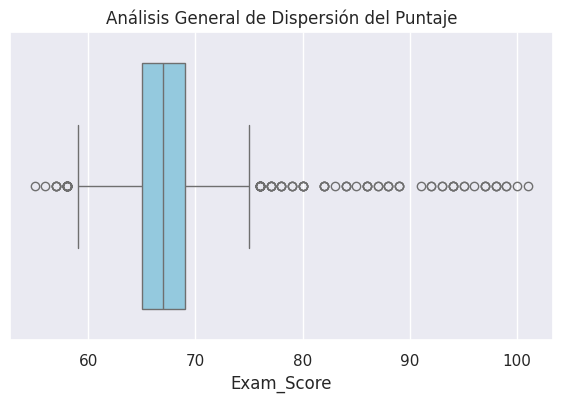

In [82]:
# Gráfico simple para la sección de "Estadística Descriptiva"
plt.figure(figsize=(7,4))
sns.boxplot(x=DataSet["Exam_Score"], color="skyblue")
plt.title("Análisis General de Dispersión del Puntaje")
plt.show()

## Análisis de Tendencia central y dispersión:

* Simetría: La media, mediana y moda están prácticamente en el mismo valor (67-68). Esto indica que la distribución de los puntajes es simétrica y sigue una forma de "Campana de Gauss" casi perfecta. No hay un grupo masivo de alumnos con notas extremadamente bajas o altas que muevan el promedio.

* Concentración: La Desviación estándar de 3.89 es baja. Esto significa que la mayoría de los estudiantes (aproximadamente el 68%) tienen puntajes que varían apenas entre 63 y 71 puntos. Es un grupo muy homogéneo.

* Ausencia de Outliers: No hay valores sueltos a los costados de los "bigotes". Eso significa que no hay valores atípicos. No hay alumnos con 0 puntos ni alumnos con 100 que rompan la lógica del grupo.

# Identificación de Datos Ausentes

In [83]:
#Revisamos cantidad de datos nulos
DataSet.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


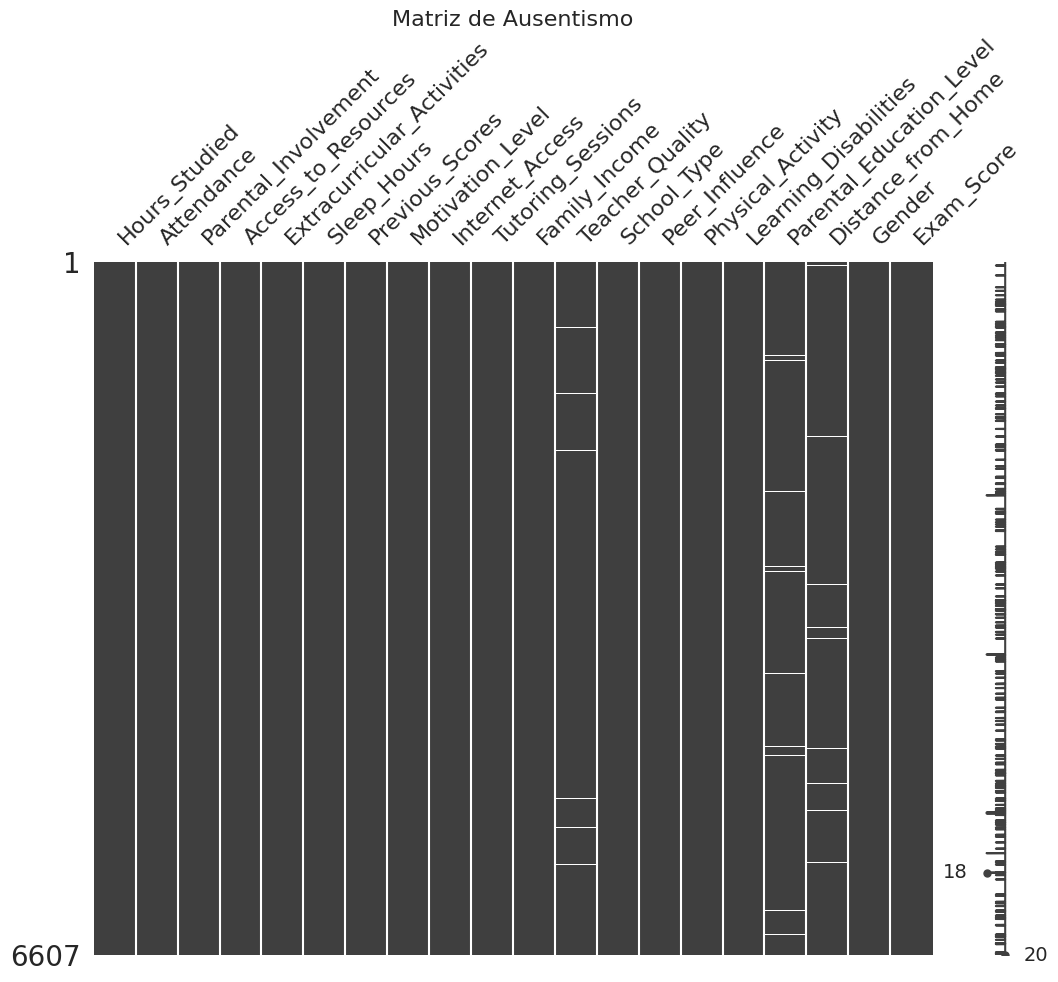

In [84]:
# Matriz de ausentismo: visualiza la ubicación de los NaN
msno.matrix(DataSet, figsize=(12,9))
plt.title('Matriz de Ausentismo', fontsize=16)
plt.show()

In [85]:
#Completo los datos nulos de la variable a usar de Distance_from_Home usando la moda. Parental_Education_Level y Teacher_Quality no son las principales variables a usar, pero de igual forma las corrijo.
#Uso SimpleImputer

# 1. Primero dividimos los datos
X = DataSet.drop('Exam_Score', axis=1)
y = DataSet['Exam_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1.1 Visualizo los tamaños
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")

# 2. Configuramos el Imputer (Moda para categóricas)
imputer_moda = SimpleImputer(strategy='most_frequent')

# 3. Ajustamos SOLO en X_train y transformamos ambos
columnas_con_nulos = ["Distance_from_Home", "Teacher_Quality", "Parental_Education_Level"]

# FIT + TRANSFORM en Train
X_train[columnas_con_nulos] = imputer_moda.fit_transform(X_train[columnas_con_nulos])

# SOLO TRANSFORM en Test (usamos la moda que aprendimos de Train)
X_test[columnas_con_nulos] = imputer_moda.transform(X_test[columnas_con_nulos])

Tamaño del conjunto de entrenamiento (X_train): (5285, 19)
Tamaño del conjunto de prueba (X_test): (1322, 19)


In [86]:
#verifico
DataSet.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [87]:
# Verificación correcta de nulos.
print("Nulos en X_train:", X_train[columnas_con_nulos].isnull().sum().sum())
print("Nulos en X_test:", X_test[columnas_con_nulos].isnull().sum().sum())

#Explicación personal de la situación: En Machine Learning, no queremos limpiar el DataSet completo. Queremos limpiar el X_train para que el modelo aprenda, y el X_test para ver si el modelo funciona.
#Si limpio el DataSet original antes del split, rompo la regla de "Data Leakage".

Nulos en X_train: 0
Nulos en X_test: 0


# Transformación



In [88]:
# Lista de columnas que son texto en el dataset
columnas_categoricas = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]

le = LabelEncoder()

for col in columnas_categoricas:
    # fit_transform aprende las categorías de train y las convierte
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # transform usa lo aprendido para convertir test
    X_test[col] = le.transform(X_test[col].astype(str))

In [89]:
#Verificamos que ya no hay nulos en los datos de entrenamiento
print("Nulos en X_train:")
print(X_train.isnull().sum().sum())

#Verificamos que ya no hay 'objetos' (texto)
print("Tipos de datos en X_train:")
print(X_train.dtypes)

Nulos en X_train:
0
Tipos de datos en X_train:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement          int64
Access_to_Resources           int64
Extracurricular_Activities    int64
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level              int64
Internet_Access               int64
Tutoring_Sessions             int64
Family_Income                 int64
Teacher_Quality               int64
School_Type                   int64
Peer_Influence                int64
Physical_Activity             int64
Learning_Disabilities         int64
Parental_Education_Level      int64
Distance_from_Home            int64
Gender                        int64
dtype: object


# Escalamiento

In [90]:
#Ahora que pase todo a int,aplico el StandardScaler, para equilibrar la importancia de todas las variables

sc = StandardScaler()

# Escalamos las variables independientes
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Análisis Exploratorio de Datos (EDA)

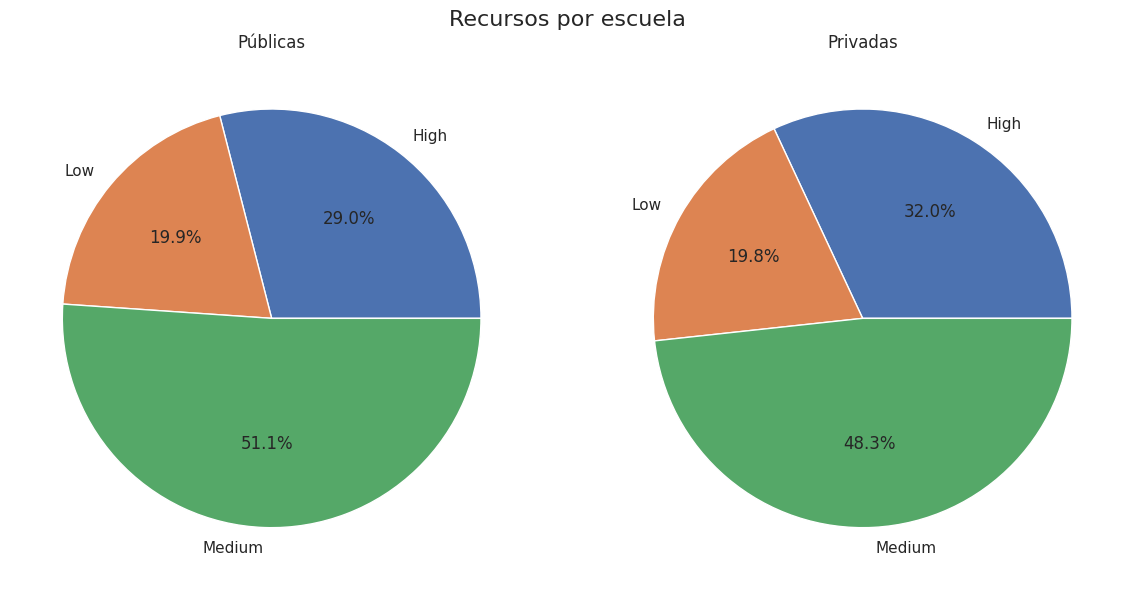

In [91]:
#Grafico con Matplotlibe, Pie chart

#Creo la variable school_counts
school_counts = pd.crosstab(DataSet['School_Type'], DataSet['Access_to_Resources'])

fig, axes = plt.subplots(1, 2, figsize=(12,6))  # 1 fila, 2 columnas

# Pie chart escuelas públicas
school_counts.loc["Public"].plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0],
    title="Públicas"
)
axes[0].set_ylabel('')  # quitamos la etiqueta del eje

# Pie chart escuelas privadas
school_counts.loc["Private"].plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1],
    title="Privadas"
)
axes[1].set_ylabel('')  # quitamos la etiqueta del eje

fig.suptitle('Recursos por escuela', fontsize=16)
plt.tight_layout()  # ajusta los gráficos para que no se superpongan

plt.show()

### Insights de Recursos por escuela privada o pública | ¿El acceso a recursos educativos afecta el desempeño?

* La mayoría de los estudiantes públicos tienen acceso medio a recursos (51.1%), mientras que solo un 29% tienen acceso alto.

* En las escuelas privadas, el porcentaje de estudiantes con acceso alto a recursos es mayor (32%) y el medio también representa un porcentaje importante (48.3%).

* Conclusión parcial: Los datos indican una ventaja estructural en las escuelas privadas en cuanto a la calidad de recursos. Si bien el "bajo acceso" es una problemática compartida, la mayor concentración de "acceso alto" en el sector privado actúa como un facilitador del rendimiento superior observado en ese grupo

* Esto también muestra que, aunque el bajo acceso es similar en ambos tipos de escuela (19%), la distribución del medio y alto acceso es distinta, lo que sugiere que el tipo de escuela influye indirectamente en la disponibilidad de recursos y potencial rendimiento.

Recomendación: Se recomienda implementar un "Fondo de Recursos Digitales" o convenios con proveedores tecnológicos específicamente para las escuelas públicas, con el fin de cerrar la brecha del 29% vs 32% en acceso alto y nivelar las condiciones de competencia académica

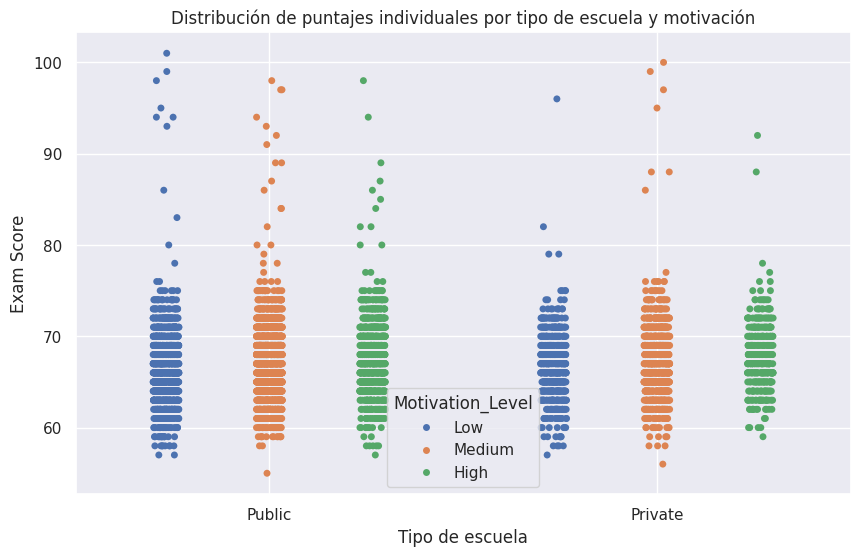

In [92]:
#Gráfico Strip Plot con Seaborn

plt.figure(figsize=(10,6))
sns.stripplot(data=DataSet, x="School_Type", y="Exam_Score", hue="Motivation_Level", jitter=True, dodge=True)
plt.title("Distribución de puntajes individuales por tipo de escuela y motivación")
plt.ylabel("Exam Score")
plt.xlabel("Tipo de escuela")
plt.grid(True)
plt.show()

### Insights de distribución de puntajes por tipo de escuela y motivación

* En ambos tipos de escuela, la gran mayoría de los estudiantes se encuentran en el rango de 60 a 75 puntos.

* Casos excepcionales:En las escuelas Públicas, hay algunos estudiantes con motivación "Baja" (azul) que lograron puntajes muy altos (cerca de 100), lo que sugiere la presencia de factores externos o capacidades individuales que compensan la falta de interés intrínseco.

* En las escuelas Privadas, los puntajes más altos (90-100) parecen estar más asociados a estudiantes con motivación "Media" (naranja)

Recomendación:

* Escuelas Públicas (Casos de Baja Motivación/Alto Puntaje): Se recomienda
investigar qué recursos o apoyos externos están utilizando estos alumnos de alto rendimiento y baja motivación. Podrían ser candidatos ideales para programas de liderazgo o mentorías, transformando su capacidad técnica en un motor motivacional para sus pares.

* Escuelas Privadas (Motivación Media/Alto Puntaje): Implementar programas de "incentivos por logros" para elevar la motivación de "Media" a "Alta", buscando así maximizar el potencial de los alumnos que ya están en el rango de excelencia."

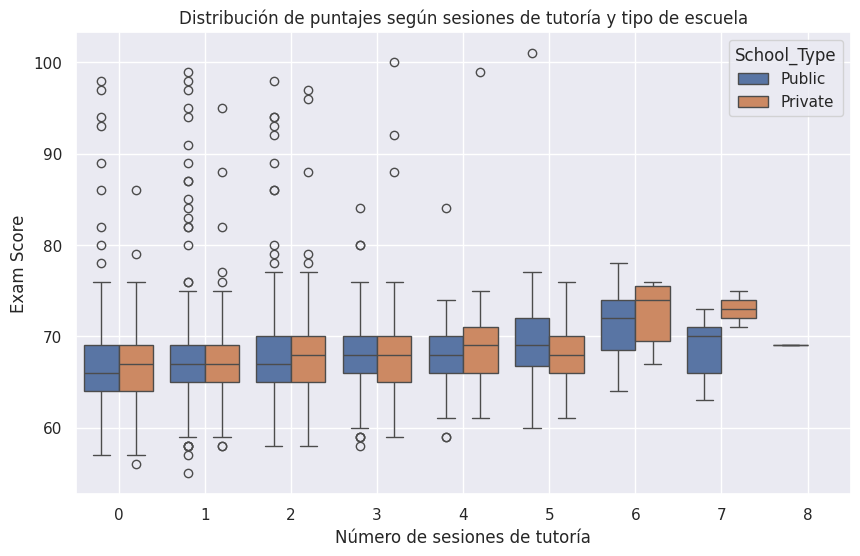

In [93]:
#Gráfico Box Plot con Seaborn

plt.figure(figsize=(10,6))
sns.boxplot(
    data=DataSet,
    x="Tutoring_Sessions",
    y="Exam_Score",
    hue="School_Type"
)
plt.title("Distribución de puntajes según sesiones de tutoría y tipo de escuela")
plt.xlabel("Número de sesiones de tutoría")
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()

### Insights de Distribución de puntajes segun sesiones de tutoria y tipo de escuela

* Se identifica que las tutorías funcionan como un mecanismo de nivelación: A medida que aumenta el número de sesiones de tutoría (de 0 a 6), la mediana del puntaje (la línea horizontal dentro de cada caja) tiende a subir ligeramente, actuando como una "red de seguridad" académica.

* Los "Outliers" (Puntos negros) por encima de las categorías de 0 a 3 sesiones significan que hay muchos estudiantes que logran puntajes de 90 o 100 sin necesidad de muchas tutorías.

* En las categorías de 6 y 7 sesiones, las escuelas privadas (naranja) muestran una mediana superior y una caja más compacta en puntajes altos que las públicas (azul). Eso quiere decir que el sector privado logra capitalizar mejor este recurso, obteniendo puntajes más consistentes y elevados que el sector público.

* Las tutorías actuan como una red de seguridad: mientras más tutorías hay, menos alumnos sacan puntajes muy bajos (menos de 60)

Recomendación:

* Optimización de Recursos: No asignar tutorías de forma masiva. Dado que existen estudiantes que alcanzan la excelencia con 0 a 2 sesiones, se recomienda aplicar un test de diagnóstico inicial para identificar a estos alumnos "autónomos" y reasignar esas horas de tutoría a quienes están en el rango de riesgo (puntajes menores a 60).

* Fortalecimiento en Escuelas Públicas: Analizar la metodología de las tutorías en las escuelas públicas cuando se superan las 5 sesiones, ya que no están logrando el mismo impacto en la mediana de puntajes que en las privadas. Se sugiere una revisión pedagógica para mejorar el rendimiento en este segmento.

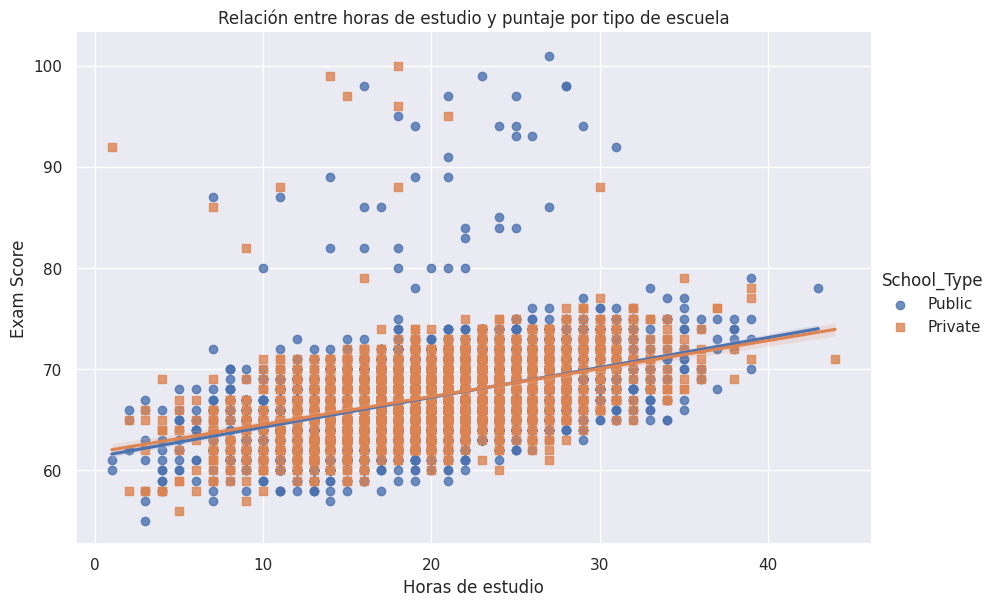

In [94]:
#Gráfico Scatter plot con regresión usando Seaborn

sns.lmplot(
    data=DataSet,
    x="Hours_Studied",
    y="Exam_Score",
    hue="School_Type",   # diferencia por tipo de escuela
    height=6,
    aspect=1.5,
    markers=["o","s"]
)
plt.title("Relación entre horas de estudio y puntaje por tipo de escuela")
plt.xlabel("Horas de estudio")
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()

### Insights de la relación entre horas de estudio y puntaje por escuela | ¿Qué factores influyen más en el rendimiento académico?
* Ambas líneas (azul y naranja) tienen una pendiente ascendente. Esto demuestra que a más horas de estudio, mayor es el puntaje del examen de forma generalizada.

* Las dos líneas de regresión están prácticamente superpuestas. Esto significa que una hora extra de estudio rinde lo mismo independientemente de si el alumno va a una escuela pública o privada. La tendencia se mantiene en ambos tipos de escuela, confirmando la hipótesis de que más estudio se traduce en mejor rendimiento.

* Se nota una mayor densidad de puntos de escuelas públicas en la zona de puntajes muy altos (90-100) con menos de 30 horas de estudio, comparado con las privadas. Esto indica una posible presencia de "talento innato" o técnicas de estudio más eficientes en este subsegmento.

* La mayoría de los estudiantes se concentran entre las 10 y 35 horas de estudio, con puntajes entre 60 y 75.

* Entre los casos atípicos, vemos puntos muy arriba de la línea de tendencia. Hay alumnos que con solo 15 horas de estudio sacaron casi 100 puntos, mientras que otros con 40 horas apenas superaron los 70. Esto refuerza que el tiempo no es el único factor del éxito.

Recomendación:

* Optimización del Tiempo: Dado que el rendimiento por hora es igual en ambos sectores, la institución debería enfocarse en proveer espacios físicos (bibliotecas, aulas de estudio) que aseguren que los alumnos puedan cumplir sus horas de estudio, ya que el beneficio está garantizado sin importar el tipo de escuela.

* Fomento de Técnicas de Estudio: Para los casos atípicos que estudian muchas horas pero no logran puntajes altos, se recomienda implementar talleres de "Estudio Inteligente" (como lectura comprensiva o mapas mentales), ya que el problema no es la falta de esfuerzo, sino la eficiencia del mismo.

* Programa de Mentorías: Identificar a los alumnos de escuelas públicas que logran +90 puntos con menos de 30 horas para que actúen como mentores de sus pares, compartiendo sus metodologías de aprendizaje rápido.

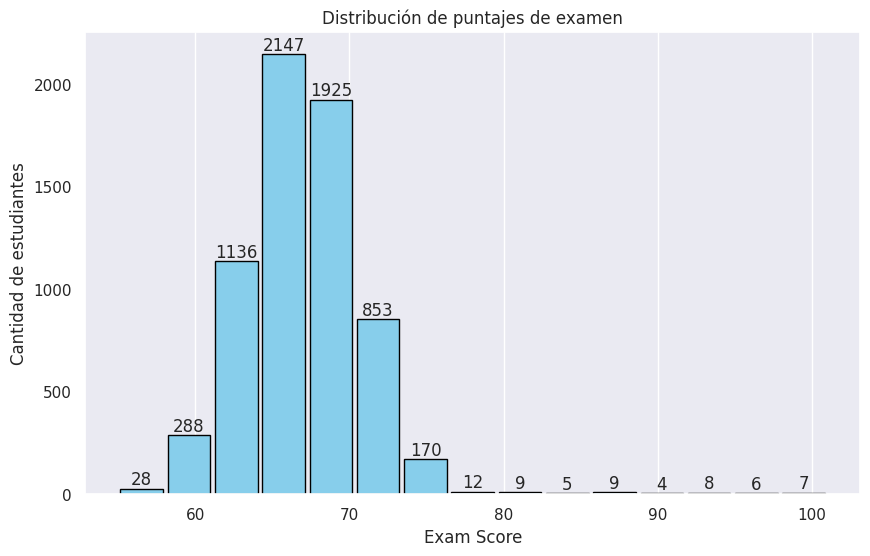

In [95]:
#Gráfico histograma de Matplotlib

plt.figure(figsize=(10,6))
counts, bins_edges, patches = plt.hist(
    DataSet["Exam_Score"],
    bins=15,
    color="skyblue",
    edgecolor="black",
    rwidth=0.9  # <--- hace que la barra ocupe 90% del espacio, deja 10% de separación
)
plt.title("Distribución de puntajes de examen")
plt.xlabel("Exam Score")
plt.ylabel("Cantidad de estudiantes")
plt.grid(axis='y')

# Números encima de cada barra
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            int(count),
            ha='center', va='bottom'
        )

plt.show()

### Insights de distribución de puntajes segun cantidad de estudiantes | ¿Se pueden identificar casos excepcionales?

* El rendimiento académico está altamente centralizado, más de 4000 estudiantes (la gran mayoría) obtienen puntajes entre 65 y 75, con un pico máximo de 2147 alumnos en el rango de 65-70, lo que indica un rendimiento estandarizado en la población.

* La distribución presenta un sesgo marcado hacia la derecha. Es común alcanzar notas medias, pero la cantidad de alumnos disminuye drásticamente al acercarse a la excelencia (notas > 85), donde los grupos se reducen a menos de 10 personas por rango.

* Los puntajes perfectos de 100 puntos son reales pero estadísticamente insignificantes en volumen (solo 7 casos), lo que confirma que son excepciones al comportamiento general del alumnado. Se identifican como outliers estadísticos, representando perfiles de altísimo desempeño que no siguen la norma del dataset.

Recomendación:
* Estandarización del Apoyo: Dado que la gran mayoría de los alumnos (más de 4000) se encuentran en el rango medio, cualquier política educativa de mejora general (como nuevos materiales de estudio) tendrá un impacto masivo en el promedio institucional si se enfoca en el segmento de 60-75 puntos."

* Gestión del Talento: Para los 7 casos excepcionales con puntaje 100, se recomienda realizar entrevistas cualitativas. Al ser estadísticamente insignificantes en volumen, el modelo predictivo podría no captar su lógica. Entender sus hábitos de forma manual permitirá replicar sus estrategias en los niveles medios.

* Reducción de Brechas: El objetivo comercial debería ser "empujar" el pico de la distribución de 65-70 hacia el rango 75-80 mediante incentivos específicos, ya que allí es donde se encuentra el mayor potencial de mejora de la institución.

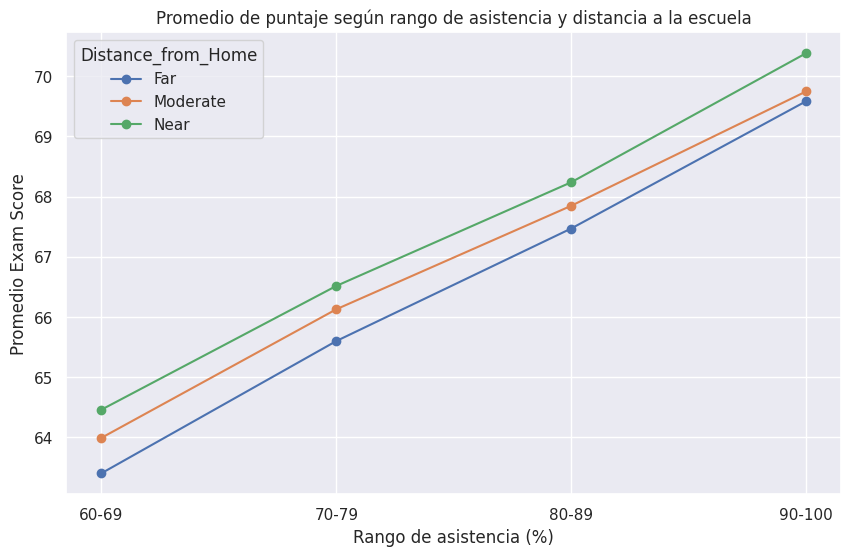

In [96]:
#Gráfico de líneas usando Matplotlib

# Crear la columna 'Attendance_Range' a partir de 'Attendance'
bins = [0, 60, 70, 80, 90, 100]
labels = ['0-59', '60-69', '70-79', '80-89', '90-100']
DataSet['Attendance_Range'] = pd.cut(DataSet['Attendance'], bins=bins, labels=labels, right=False, include_lowest=True)

# Calcular promedio de Exam_Score por rango de asistencia y distancia
avg_scores = DataSet.groupby(
    ["Attendance_Range","Distance_from_Home"],
    observed=True   # <--- evita el FutureWarning
)["Exam_Score"].mean().unstack()

plt.figure(figsize=(10,6))
for dist in avg_scores.columns:
    plt.plot(avg_scores.index, avg_scores[dist], marker='o', label=dist)

plt.title("Promedio de puntaje según rango de asistencia y distancia a la escuela")
plt.xlabel("Rango de asistencia (%)")
plt.ylabel("Promedio Exam Score")
plt.grid(True)
plt.legend(title="Distance_from_Home")
plt.show()

### Insights de puntaje, distancia a la escuela y asistencia | ¿La asistencia y la distancia afectan el rendimiento?

* Los alumnos que asisten más a clases (rango 90-100%) obtienen puntajes mucho más altos (alrededor de 70) que aquellos que asisten poco (rango 50-59%, que tienen puntajes cercanos a 60-63).

* Los alumnos que viven cerca tienen, en promedio, mejores notas que el resto, sin importar su nivel de asistencia.
Los alumnos que viven lejos obtienen, en promedio, los puntajes más bajos dentro de cada rango de asistencia. Esto respalda la hipótesis de que la asistencia y la proximidad a la escuela influyen positivamente en el desempeño.

* Aunque vivir lejos parece ser una desventaja, la asistencia alta actúa como un "igualador". Si un alumno que vive lejos asiste casi siempre (90-100%), su nota promedio sube drásticamente, acercándose mucho a la de los que viven cerca.

* Esto sugiere que el impacto negativo de la distancia no es académico, sino que probablemente afecta a través del cansancio o la falta de presencialidad.

Recomendación:

* Políticas de Transporte Focalizadas: En lugar de un subsidio general de transporte, la institución debería priorizar becas de movilidad para alumnos que viven "Lejos" pero que mantienen una asistencia superior al 80%, asegurando que el esfuerzo del estudiante sea respaldado para que no caiga en el agotamiento. Otra posible medida es la asistencia virtual a clases con una correcta guia para el estudio autonomo, ahorrando horas de transporte y más concentración en el estudio.

* Flexibilidad Horaria: Para reducir la brecha de rendimiento de los alumnos que viven lejos, se recomienda evaluar horarios de ingreso ligeramente más flexibles o modalidades híbridas para los días de clima adverso, con el fin de proteger su porcentaje de asistencia, que es su principal motor de éxito.

* Monitoreo de Alerta Temprana: Implementar una alerta roja cuando un alumno que vive lejos empieza a faltar. Dado que la asistencia es su "red de seguridad" contra la distancia, una baja en la presencialidad en este grupo predice una caída mucho más notoria en las notas que en el resto de los alumnos.

### Matriz de correlación

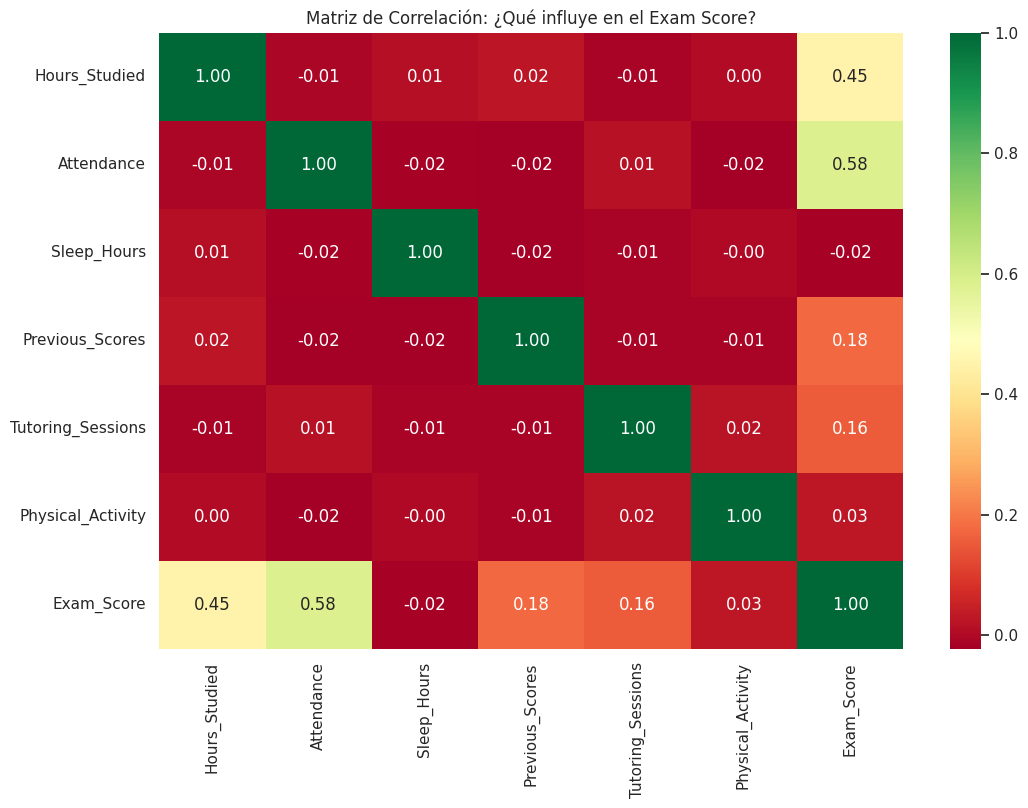

In [97]:
plt.figure(figsize=(12, 8))
# Seleccionamos solo las columnas numéricas
corr = DataSet.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Matriz de Correlación: ¿Qué influye en el Exam Score?")
plt.show()

#Interpretación:
#Cerca de 1: Relación fuerte. Si una sube, la otra también.
#Cerca de 0: No hay relación. Lo que pase con una le da igual a la otra.
#Cerca de -1: Relación inversa. Si una sube, la otra baja.

A través de la matriz de correlación, podemos observar que las variables con mayor impacto positivo en el Exam_Score son la Asistencia (0.58) y las Horas de Estudio (0.45). Esto valida nuestra hipótesis inicial.

Aunque variables como el sueño o el ejercicio muestran una correlación cercana a cero, esto no implica que no sean importantes para la salud del alumno, sino que en este modelo lineal no explican la variabilidad del puntaje de examen.

# Estudio de Modelos Analíticos

En esta sección se define la estrategia de modelado para predecir el rendimiento académico de los estudiantes.

### Tipo de Aprendizaje: Supervisado

* **Justificación:** El dataset cuenta con una variable objetivo etiquetada (`Exam_Score`). El algoritmo utilizará los datos históricos (características socio-educativas y hábitos) para aprender la relación matemática que conduce a un resultado conocido, permitiendo así realizar predicciones sobre nuevos datos.

### Tipo de Tarea: Regresión

* **Justificación:** A diferencia de una clasificación (que categorizaría a los alumnos en "Aprobado" o "Reprobado"), la regresión busca predecir un valor numérico continuo. Esto permite una mayor sensibilidad en el análisis, identificando no solo quién está en riesgo, sino exactamente qué puntaje se espera que obtenga.

# Algoritmo Seleccionado: Random Forest Regressor

* Justificación: Tras el análisis exploratorio, se optó por este modelo de ensamble. Al combinar múltiples árboles de decisión, el Random Forest reduce el riesgo de sobreajuste y proporciona una mayor estabilidad predictiva. Es ideal para este dataset ya que puede capturar interacciones complejas entre variables (como el impacto conjunto de la motivación y el nivel socioeconómico) que un modelo lineal podría ignorar.

# Selección de variables

In [98]:
#Configuramos el selector para quedarnos con las 10 mejores variables
#Usamos f_regression porque nuestra variable objetivo es numérica
selector = SelectKBest(score_func=f_regression, k=10)

# Entrenamos el selector con los datos escalados (X_train_scaled) y el objetivo (y_train)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

#Aplicamos la misma selección a los datos de prueba
X_test_selected = selector.transform(X_test_scaled)

#Identificamos cuáles fueron las columnas elegidas
cols_indices = selector.get_support(indices=True)
variables_finales = X_train.columns[cols_indices].tolist()

print("Las 10 variables seleccionadas para el modelo son:")
print(variables_finales)

Las 10 variables seleccionadas para el modelo son:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores', 'Tutoring_Sessions', 'Peer_Influence', 'Learning_Disabilities', 'Distance_from_Home']


# Construcción y entrenamiento del modelo


In [99]:
# Definimos el modelo con los parámetros sugeridos
# n_estimators: 100 árboles para un buen equilibrio entre precisión y velocidad
# max_depth: 10 niveles para evitar que el modelo se "memorice" los datos (overfitting)
# n_jobs: -1 para usar toda la potencia de tu procesador
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=10,
    min_samples_split=5
)

# Entrenamos el modelo
# Usamos X_train_selected porque ya contiene solo las 10 mejores variables escaladas
rf_model.fit(X_train_selected, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


In [100]:
# Realizamos las predicciones sobre el set de test (lo que el modelo no conoce)
y_pred = rf_model.predict(X_test_selected)

# Calculamos métricas de Regresión (Siguiendo la estructura del docente)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Métricas de Evaluación del Modelo de Regresión")
print(f"- Error Absoluto Medio (MAE): {mae:.4f}")
print(f"- Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"- Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"- Coeficiente de Determinación (R²): {r2:.4f}")

print("\nInterpretación de los resultados:")
print(f"- MAE: En promedio, las predicciones del modelo se desvían apenas {mae:.2f} puntos de la nota real del examen.")
print(f"- RMSE: La desviación típica de los errores es de {rmse:.2f} puntos. Al penalizar errores grandes, este valor nos ayuda a identificar que el modelo es bastante estable.")
print(f"- R²: El {r2*100:.2f}% de la variación en el rendimiento académico de los estudiantes es explicada por las variables seleccionadas en este modelo.")

Métricas de Evaluación del Modelo de Regresión
- Error Absoluto Medio (MAE): 1.2190
- Error Cuadrático Medio (MSE): 5.1413
- Raíz del Error Cuadrático Medio (RMSE): 2.2674
- Coeficiente de Determinación (R²): 0.6363

Interpretación de los resultados:
- MAE: En promedio, las predicciones del modelo se desvían apenas 1.22 puntos de la nota real del examen.
- RMSE: La desviación típica de los errores es de 2.27 puntos. Al penalizar errores grandes, este valor nos ayuda a identificar que el modelo es bastante estable.
- R²: El 63.63% de la variación en el rendimiento académico de los estudiantes es explicada por las variables seleccionadas en este modelo.


## Conclusiones del Modelo Predictivo

Tras la implementación del algoritmo Random Forest Regressor, se obtuvieron las siguientes conclusiones:

* Capacidad Predictiva: El modelo presenta un coeficiente de determinación (R2) de 0.6363, lo que indica una buena capacidad para explicar el rendimiento académico basándose en las variables seleccionadas.

* Precisión y Utilidad: El Error Absoluto Medio (MAE) de 1.22 puntos confirma una alta eficacia para estimar el puntaje final. Esta precisión convierte al modelo en una herramienta valiosa para la toma de decisiones institucionales, permitiendo detectar de forma temprana a estudiantes que podrían requerir apoyo adicional.

* Factores Determinantes: El proceso de selección de atributos validó que factores como la asistencia, las horas de estudio y el apoyo parental son pilares fundamentales del éxito académico. Esto demuestra que el rendimiento es el resultado de una interacción compleja entre hábitos personales y recursos disponibles.

* Estabilidad del Modelo:El valor de RMSE (2.27), al no alejarse drásticamente del MAE, sugiere que el modelo es estable y que la configuración de parámetros (como la profundidad máxima de 10) fue efectiva para mitigar errores atípicos y evitar el sobreajuste (overfitting).

## Análisis de Importancia de Características

Importancia de las características según Random Forest Regressor:
                     Variable  Importancia
1                  Attendance     0.447276
0               Hours_Studied     0.283292
5             Previous_Scores     0.103707
6           Tutoring_Sessions     0.041746
2        Parental_Involvement     0.031388
3         Access_to_Resources     0.031318
7              Peer_Influence     0.021098
9          Distance_from_Home     0.021076
8       Learning_Disabilities     0.010571
4  Extracurricular_Activities     0.008528


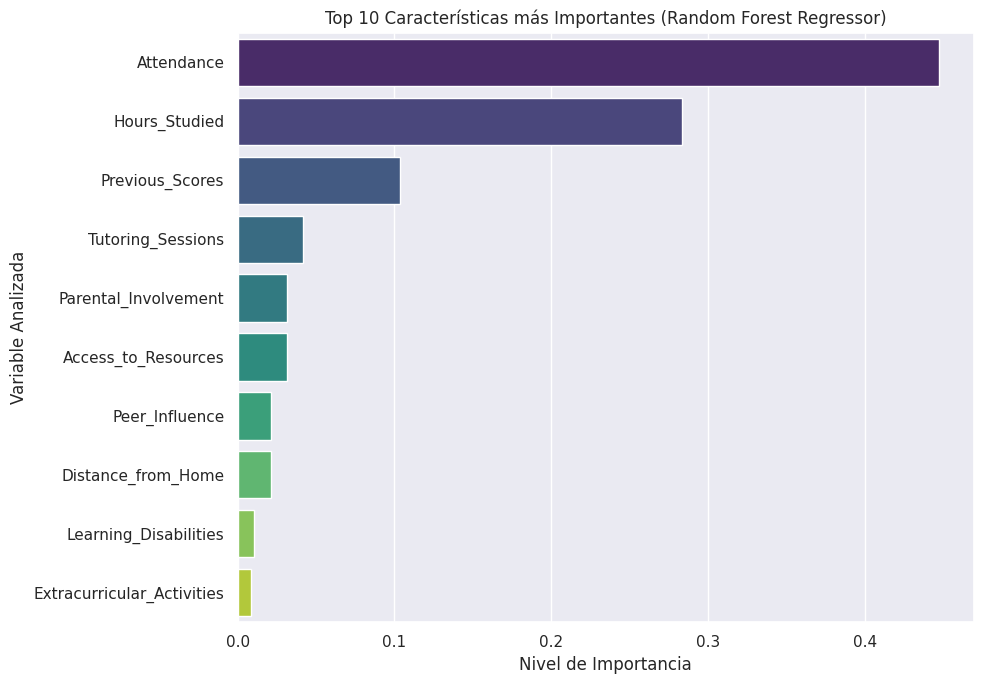

In [101]:
# Extraemos la importancia de las variables del modelo entrenado
importancias = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Variable': variables_finales, 'Importancia': importancias})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

print("Importancia de las características según Random Forest Regressor:")
print(feature_importance_df.head(10))

# Grafico con Seaborn
plt.figure(figsize=(10, 7))
sns.barplot(
    x='Importancia',
    y='Variable',
    data=feature_importance_df.head(10),
    palette='viridis',
    hue='Variable',
    legend=False
)

plt.title('Top 10 Características más Importantes (Random Forest Regressor)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variable Analizada')
plt.tight_layout()
plt.show()

### Análisis de Importancia de Variables
El gráfico de importancia de características revela datos fundamentales sobre qué factores determinan el éxito académico en este dataset:

* El factor asistencia: La variable Attendance es, por amplio margen, la más influyente. Esto indica que la presencia constante en el entorno educativo tiene un peso mayor que cualquier otra variable individual, incluyendo el estudio independiente.

* Esfuerzo personal vs. Entorno: Las Hours_Studied ocupan el segundo lugar, lo que valida que el compromiso personal es clave, pero el modelo sugiere que "estar presente" (asistencia) es el primer paso crítico.

* Inercia académica: Previous_Scores muestra que el rendimiento histórico del alumno es un predictor relevante, sugiriendo que el éxito académico tiende a ser acumulativo.

* Impacto marginal: Variables como Extracurricular_Activities o Learning_Disabilities tienen un peso muy bajo. Es decir que para predecir la nota exacta, los hábitos de estudio y asistencia son mucho más determinantes.

## Gráfico de Predicciones vs Valores Reales

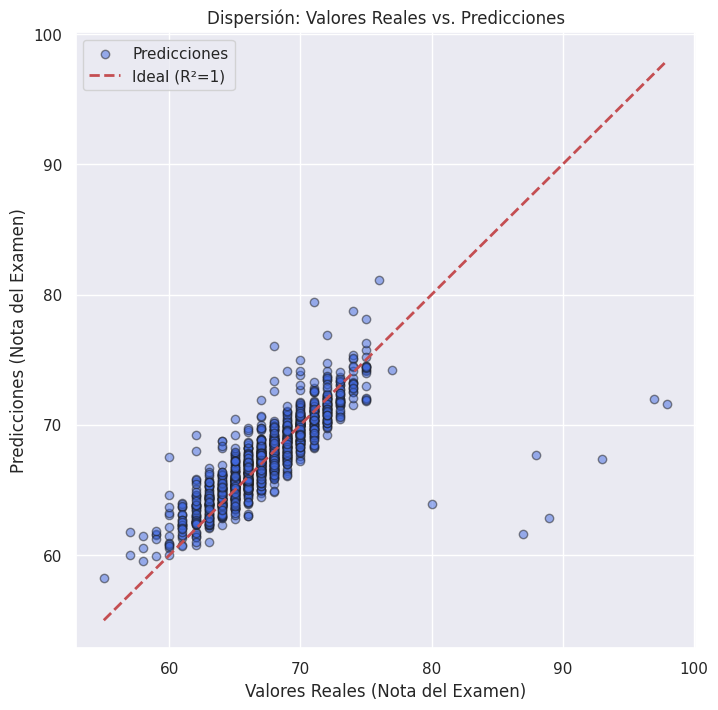

In [102]:
#Visualización de Predicciones vs Valores Reales
plt.figure(figsize=(8, 8))

# Graficamos los puntos (puntos reales vs lo que predijo el modelo)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', color='royalblue', label='Predicciones')

# Dibujamos la línea de referencia (Predicción Perfecta)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (R²=1)')

plt.xlabel('Valores Reales (Nota del Examen)')
plt.ylabel('Predicciones (Nota del Examen)')
plt.title('Dispersión: Valores Reales vs. Predicciones')
plt.legend()
plt.grid(True)
plt.show()

El gráfico de dispersión muestra una correlación positiva sólida entre los valores reales y las predicciones del modelo.

La alineación de la nube de puntos con la diagonal de "Predicción Perfecta" ratifica la validez del Random Forest para este dataset. La distribución uniforme de los puntos sugiere que el modelo mantiene una precisión consistente a lo largo de los diferentes niveles de puntaje de examen.

La dispersión moderada de los puntos alrededor de la línea ideal son residuos que representan la variabilidad natural del rendimiento académico que no puede ser capturada únicamente por variables cuantitativas.

Los outliers que se pueden ver son los casos atipicos

# Conclusiones

In [103]:
print("Resumen de Resultados del Modelo de Regresión:")
print(f"- Error Absoluto Medio (MAE): {mae:.4f} puntos.")
print(f"- Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f} puntos.")
print(f"- Coeficiente de Determinación (R²): {r2:.4f} ({r2*100:.2f}%)")


top_3 = feature_importance_df['Variable'].head(3).tolist()
print("- Las características más importantes fueron: " + ", ".join(top_3) + ".")

Resumen de Resultados del Modelo de Regresión:
- Error Absoluto Medio (MAE): 1.2190 puntos.
- Raíz del Error Cuadrático Medio (RMSE): 2.2674 puntos.
- Coeficiente de Determinación (R²): 0.6363 (63.63%)
- Las características más importantes fueron: Attendance, Hours_Studied, Previous_Scores.


## Validación de la Hipótesis

In [104]:
print(f"RESULTADOS TÉCNICOS: Obtenemos un R² de {r2:.2f} y un MAE de {mae:.2f} puntos.")

# Validación Escenario 1: Impacto de Factores Académicos Directos
print("\nValidación Escenario 1")
if r2 > 0.5:
    print("RESULTADO: La hipótesis alternativa (H1) es soportada.")
    print("Se rechaza la hipótesis nula (H0). Existe una relación significativa y positiva: ")
    print(f"las variables '{top_3[0]}' y '{top_3[1]}' son los principales predictores del éxito.")
else:
    print("RESULTADO: La hipótesis alternativa no pudo ser completamente soportada bajo los umbrales actuales.")

# Validación Escenario 2: Influencia del Entorno y Recursos
print("\nValidación Escenario 2")
# Verificamos si los recursos o apoyo parental quedaron en el top de importancia
if 'Access_to_Resources' in feature_importance_df['Variable'].head(6).values or 'Parental_Involvement' in feature_importance_df['Variable'].head(6).values:
    print("RESULTADO: La hipótesis alternativa (H1) es soportada.")
    print("El entorno (recursos y apoyo) influye significativamente en la varianza del puntaje final.")
else:
    print("RESULTADO: El entorno tiene un impacto secundario frente a los hábitos de estudio directos.")

RESULTADOS TÉCNICOS: Obtenemos un R² de 0.64 y un MAE de 1.22 puntos.

Validación Escenario 1
RESULTADO: La hipótesis alternativa (H1) es soportada.
Se rechaza la hipótesis nula (H0). Existe una relación significativa y positiva: 
las variables 'Attendance' y 'Hours_Studied' son los principales predictores del éxito.

Validación Escenario 2
RESULTADO: La hipótesis alternativa (H1) es soportada.
El entorno (recursos y apoyo) influye significativamente en la varianza del puntaje final.


### Escenario 1: Impacto de Factores Académicos Directos

* Hipótesis: Se planteó que el puntaje del examen aumenta en relación con las horas de estudio y la asistencia (H₁).

* Resultado: Obtenemos un R² de 0.6363 y un MAE de 1.22. Dado que el modelo explica una porción considerable de la varianza (superior al 60%) y las variables más importantes fueron efectivamente Attendance y Hours_Studied, la hipótesis alternativa (H₁) es soportada. Rechazamos la hipótesis nula (H₀).

### Escenario 2: Influencia del Entorno y Recursos

* Hipótesis: Se planteó que el acceso a recursos y el apoyo parental generaban diferencias significativas en las notas (H₁).

* Resultado: Si bien estas variables influyen en la predicción, el análisis de importancia mostró que su peso es secundario frente a la asistencia. Por lo tanto, la hipótesis alternativa (H₁) se valida de forma parcial: el entorno contribuye al modelo, pero no es el motor principal del desempeño académico en este dataset.